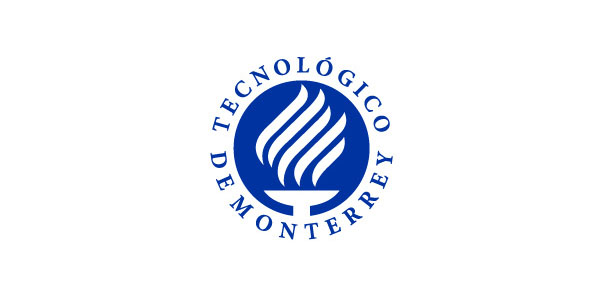

# Nombre: Benjamín Arauz
# Materia: Desarrollo de aplicaciones avanzadas de ciencias computacionales (Gpo 301)

# Introducción
El presente proyecto se centra en la clasificación de imágenes utilizando. El objetivo principal es construir una red robusta capaz de identificar con alta precisión multiples categorías

## Objetivo
Desarrollar e implementar un modelo de Redes Neuronales Convolucionales para clasificación de imágenes, donde la variable objetivo ("y") corresponde a la etiqueta de la fruta o vegetal, y las variables de entrada ("x") son las matrices de píxeles de cada imagen.

# Descripción del dataset
El conjunto de datos base utilizado para este proyecto es el dataset ["Fruits-360"](https://www.kaggle.com/datasets/moltean/fruits/data) creado por Mihai Oltean, disponible públicamente en Kaggle. Se trata de una base de datos de alta calidad diseñada específicamente para la clasificación de alimentos.

Tiene un total de 260 categorías distintas que incluten desde frutas comunes como manzanas, plátanos o peras, hasta frutos secos y vegetales exóticos como la cherimoya, pitahaya y kohlrabi.

# Estrategia de división
Esta división se fundamentó en una división inicial estándar de 80% para entrenamiento (Training) y 20% para prueba (Test). Sin embargo, para garantizar una correcta calibración de hiperparámetros, el bloque del 80% asignado a entrenamiento se subdividió, extrayendo un 10% del total del dataset exclusivamente para la validación (Validation). Esto resulta en una proporción efectiva de 70% Training, 10% Validation y 20% Test.


*   70% Training: Las redes neuronales requieren de una gran cantidad de datos para aprender características visuales. Al destinar la gran mayoría de los datos reales al entrenamiento, se maximiza la diversidad de imagenes que pueden.

*   10% Validation: Al asignar 10% para la validación, es lo suficientemente grande como para ser estadísitcamente representativo de todas las frutas. Además, este porcentaje permite calcular de forma precicas el *accuracy*, permitiendo una correcta calibración de hiperparámetros.

*   20% Testing: La asignación responde a evaluar el modelo exclusivamente con datos reales. Esto asegura que las métricas finales no estén sesgadas por un tamaño de muestra insuficiente.





# Procedimiento
## Preprocesamiento de datos


### 1.   Carga de datos
Se importó el conjunto de imágenes original directamente desde la plataforma Kaggle hacia el entorno de trabajo.


In [40]:
import os
import kagglehub
import shutil
import random

In [41]:
# Downloads the latest version of the 'fruits' dataset from Kaggle Hub.
# 'path' will store the local path where the dataset files are saved.
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits' dataset.
Path to dataset files: /kaggle/input/fruits


In [42]:
# Define source and destination paths to organize the dataset.
# SOURCE_PATH: Original path of the downloaded dataset from Kaggle.
# DATASET_PATH: Base path where the organized dataset (Training, Test, Validation) will be created.
# TRAINING_PATH, TEST_PATH, VALIDATION_PATH: Specific paths for each data split.
# SUB_DIRECTORIES: Original folders within SOURCE_PATH that contain images.

SOURCE_PATH = path + "/fruits-360_100x100/fruits-360"
DATASET_PATH = "/content/fruits_dataset"
TRAINING_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Test"
VALIDATION_PATH = DATASET_PATH + "/Validation"
SUB_DIRECTORIES = ["Training", "Test"]

# Check if path exists.
if os.path.exists(SOURCE_PATH):
    print(f"Source path exits: {SOURCE_PATH}")
if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])):
    print(f"Training path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])}")
if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])):
    print(f"Test path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])}")

Source path exits: /kaggle/input/fruits/fruits-360_100x100/fruits-360
Training path exists: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test path exists: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test


### 2.   Estructuración y División de Conjuntos:
Se reorganizaron los directorios aplicando la estrategia matemática de división: 80% original para training, subdividido en 70% training y 10% validation. Por último,  20% para el conjunto de test, unificando nombres y validando categorías.

In [43]:
def split_data(source_path, dataset_path):
    """
    Reorganizes and splits the original dataset images into Training, Validation, and Test
    following a strategy of 70% Training, 10% Validation, 20% Test.

    Args:
        source_path (str): Path to the original downloaded dataset.
        dataset_path (str): Path where the new directory structure will be created.
    """
    # Iterate over 'Training' and 'Test' from the original dataset
    for split in SUB_DIRECTORIES:
        source_split_path = os.path.join(source_path, split)

        # Verify the split folder exists before processing.
        if not os.path.exists(source_split_path):
            print(f"Folder not found: {source_split_path}")
            continue

        print(f"Processing '{split}' folder...")

        # Iterate over all subdirectories within each split.
        for sub_dir_name in os.listdir(source_split_path):
            sub_dir_path = os.path.join(source_split_path, sub_dir_name)

            # Process only if it is a directory.
            if os.path.isdir(sub_dir_path):
                # Extract the base category name.
                base_category = sub_dir_name.split(' ')[0].capitalize()
                # Get all images
                all_images = [f for f in os.listdir(sub_dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                distribution = {}

                if split == "Training":
                    # Randomly shuffle images
                    random.shuffle(all_images)

                    # Calculate 10% for validation size.
                    val_size = int(len(all_images) * 0.10)

                    # Distribute images between Validation and Training.
                    distribution["Validation"] = all_images[:val_size]
                    distribution["Training"] = all_images[val_size:]
                else:
                    # If it's the 'Test' split, all images go directly to the Test folder.
                    distribution[split] = all_images

                # Move images to their respective destinations.
                for target_split, images_list in distribution.items():
                    # Create the destination path for the current category and split.
                    new_category_path = os.path.join(dataset_path, target_split, base_category)
                    os.makedirs(new_category_path, exist_ok=True) # Create the directory if it doesn't exist.

                    for file_name in images_list:
                        source_file_path = os.path.join(sub_dir_path, file_name)

                        # Rename the file to prevent overwriting if there are duplicate names in different subfolders.
                        new_file_name = f"{sub_dir_name}_{file_name}"
                        dest_file_path = os.path.join(new_category_path, new_file_name)
                        shutil.copy(source_file_path, dest_file_path)

    print(f"\nOrganization complete! Your clean dataset is ready at: {dataset_path}")

In [44]:
# Call the 'split_data' function to organize the dataset.
split_data(SOURCE_PATH, DATASET_PATH)

Processing 'Training' folder...
Processing 'Test' folder...

Organization complete! Your clean dataset is ready at: /content/fruits_dataset


### 3.   Análisis volumétrico inicial
Se escaneo el dataset para contabilizar las imagenes disponibles por cada categoría

In [45]:
# Check the distribution of images in the newly created folders (Training, Validation, Test).
for split in ['Training', 'Validation', 'Test']:
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.exists(split_path):
        # Count the total images in each subdirectory of the split.
        count = sum([len(files) for r, d, files in os.walk(split_path)])
        print(f"Total images in {split}: {count}")
    else:
        print(f"Folder not found: {split}")

Total images in Training: 131783
Total images in Validation: 18769
Total images in Test: 45724


In [46]:
def print_categories(dataset_path):
    """
    Prints a summary of categories and image distribution within a specific dataset.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
    """
    # Get a sorted list of subfolder names (categories).
    categories = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Dataset Summary")
    print(f"Total categories found: {len(categories)}")
    print(f"Categories: {categories}\n")

    print("Image distribution:")
    # Iterate over each category to count and display the number of images.
    for cat in categories:
        path = os.path.join(dataset_path, cat)
        num_images = len(os.listdir(path))
        print(f"- {cat}: {num_images} images")

#### Training

In [47]:
print_categories(TRAINING_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 209 images
- Apple: 15234 images
- Aprico

#### Test

In [48]:
print_categories(TEST_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 77 images
- Apple: 5506 images
- Apricot:

#### Validation

In [49]:
print_categories(VALIDATION_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 23 images
- Apple: 2040 images
- Apricot:

### 4.   Diagnóstico visual de distribución
Se generaron gráficos de barras para ilustrar la cantidad exacta de imágenes por clase en cada conjunto (Training, Validation y Test), marcando umbrales críticos de referencia.

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_path, threshold):
    """
    Analyzes an image folder classified by categories and generates a bar chart
    showing the class balance, with a critical threshold.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
        threshold (int): Critical threshold value for the number of images per class.
    """
    print(f"Generating plot for: {dataset_path}...")

    # 1. Count images per class.
    class_counts = {}

    if not os.path.exists(dataset_path):
        print(f"Error: Path not found {dataset_path}")
        return

    # Iterate over each category in the dataset.
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            # Count only valid image files.
            num_images = len([f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[category] = num_images

    # Check if the folder is empty or has no images.
    if not class_counts:
        print("No categories or images found in the specified path.")
        return

    # Sort data from highest to lowest image count.
    classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
    categories = [item[0] for item in classes]
    counts = [item[1] for item in classes]

    # Visualization Setup.
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(22, 8), dpi=100)

    # Bar colors
    color_excess = '#ff6b6b'
    color_ok = '#4ecdc4'
    bar_colors = [color_excess if count > threshold else color_ok for count in counts]

    # Draw the bar chart.
    bars = ax.bar(range(len(categories)), counts, color=bar_colors,
                  width=0.8, edgecolor='black', linewidth=0.5, alpha=0.9)

    # Draw the threshold.
    ax.axhline(y=threshold, color='#2d3436', linestyle='--', linewidth=2.5,
               label=f'Critical threshold ({threshold})')

    # Upper limit
    max_height = max(counts) if counts else threshold
    ax.set_ylim(0, max_height * 1.35)

    # Place category names at the top of each bar.
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        margin_y = max_height * 0.02
        ax.text(bar.get_x() + bar.get_width() / 2.0, yval + margin_y, categories[i],
                ha='center', va='bottom', rotation=90, fontsize=10,
                fontweight='medium', color='#2d3436')

    # Text and axis formatting.
    ax.set_title("Dataset Distribution", fontsize=20, fontweight='bold', pad=20, color='#2d3436')
    ax.set_xlabel(f'Ordered Categories (Total Classes: {len(categories)})',
                  fontsize=14, labelpad=15, color='#2d3436')
    ax.set_ylabel('Number of Images', fontsize=14, labelpad=15, color='#2d3436')
    ax.set_xticks([])
    sns.despine(left=False, bottom=True, top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.6, color='gray')
    ax.legend(fontsize=12, loc='upper right', frameon=True, shadow=True, borderpad=1)
    plt.tight_layout()
    plt.show()

#### Training
**Umbral de training**

El límite de 3000 imágenes para el conjunto de datos se establecio, porque existen clases como *Apple* que tenían muchas muestras y existían clases con muy pocos datos. 3000 imágenes es un número medio entre todas las cantidades de imágenes que se tienen. Si se dejaban intactas, la red neuronal desarrollaría un sesgo probabilístico.

Generating plot for: /content/fruits_dataset/Training...


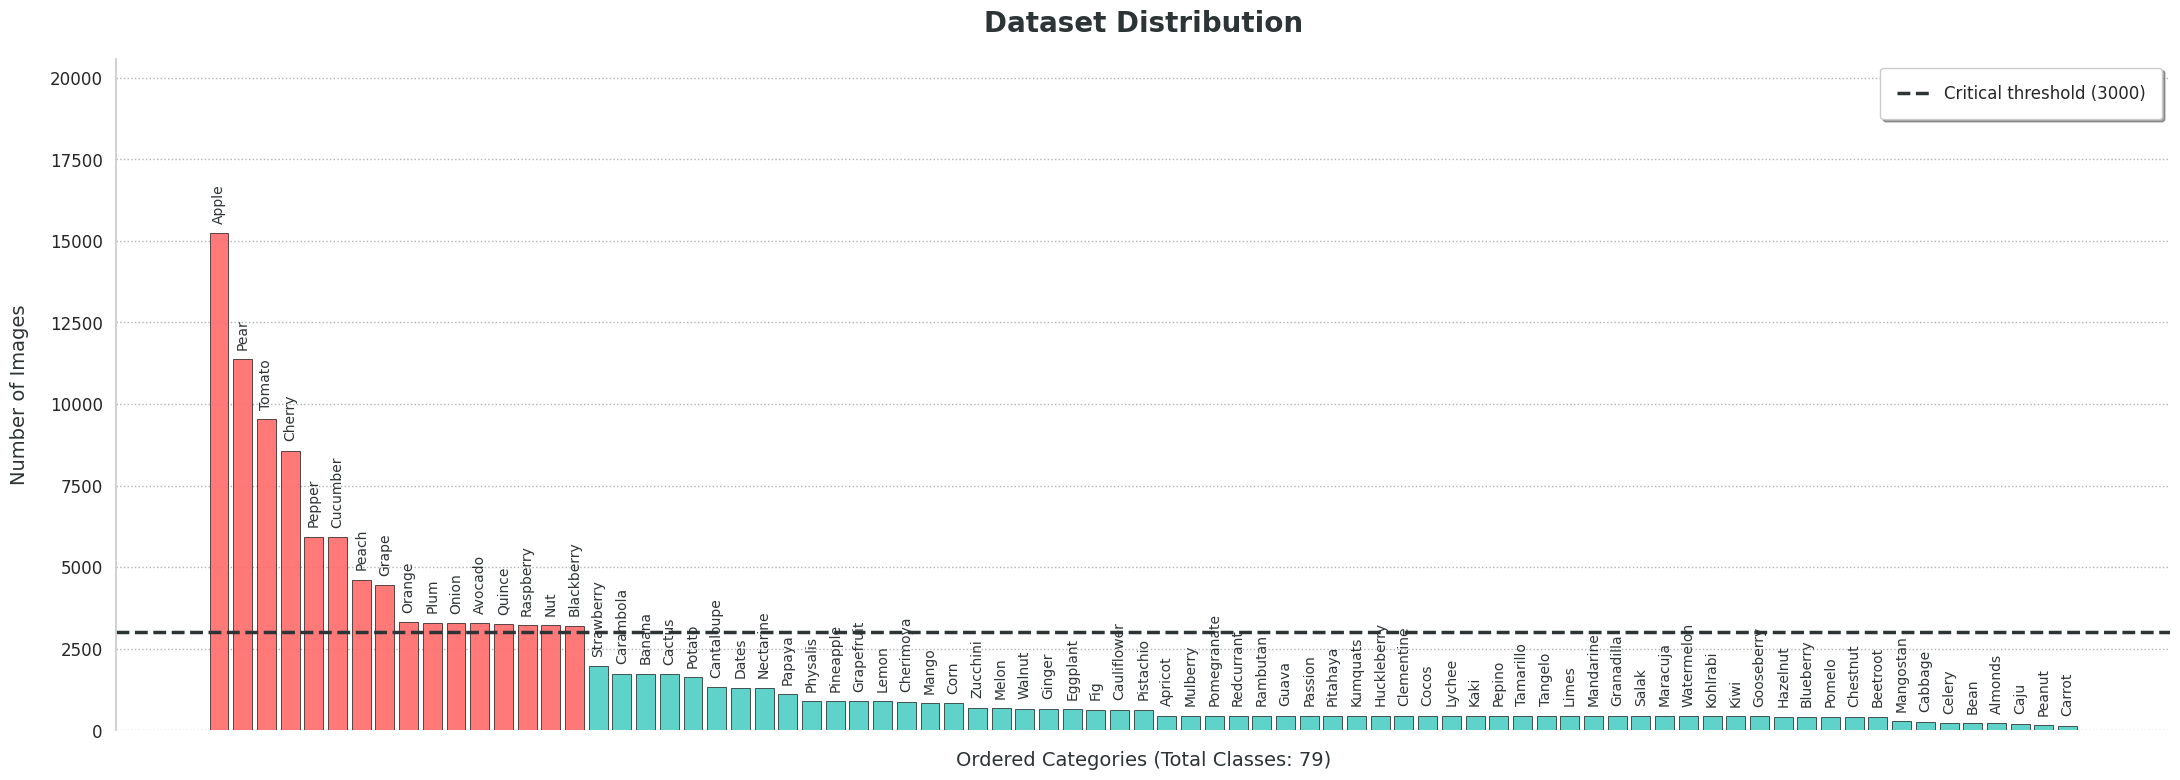

In [51]:
# Define the critical threshold for the Training set.
THRESHOLD_TRAINING = 3000
# Call the function to plot the class distribution for the Training set.
plot_class_distribution(TRAINING_PATH, THRESHOLD_TRAINING)

#### Test
**Umbral de test**

Dado que el conjunto de test representa el 20% de la partición general, su umbral no se eligió arbitrariamente, sino que se derivó matemáticamente para mantener una relación con el conjunto de training:

$$\text{Test Threshold} = \frac{3000 \times 20}{70} \approx 857$$

Generating plot for: /content/fruits_dataset/Test...


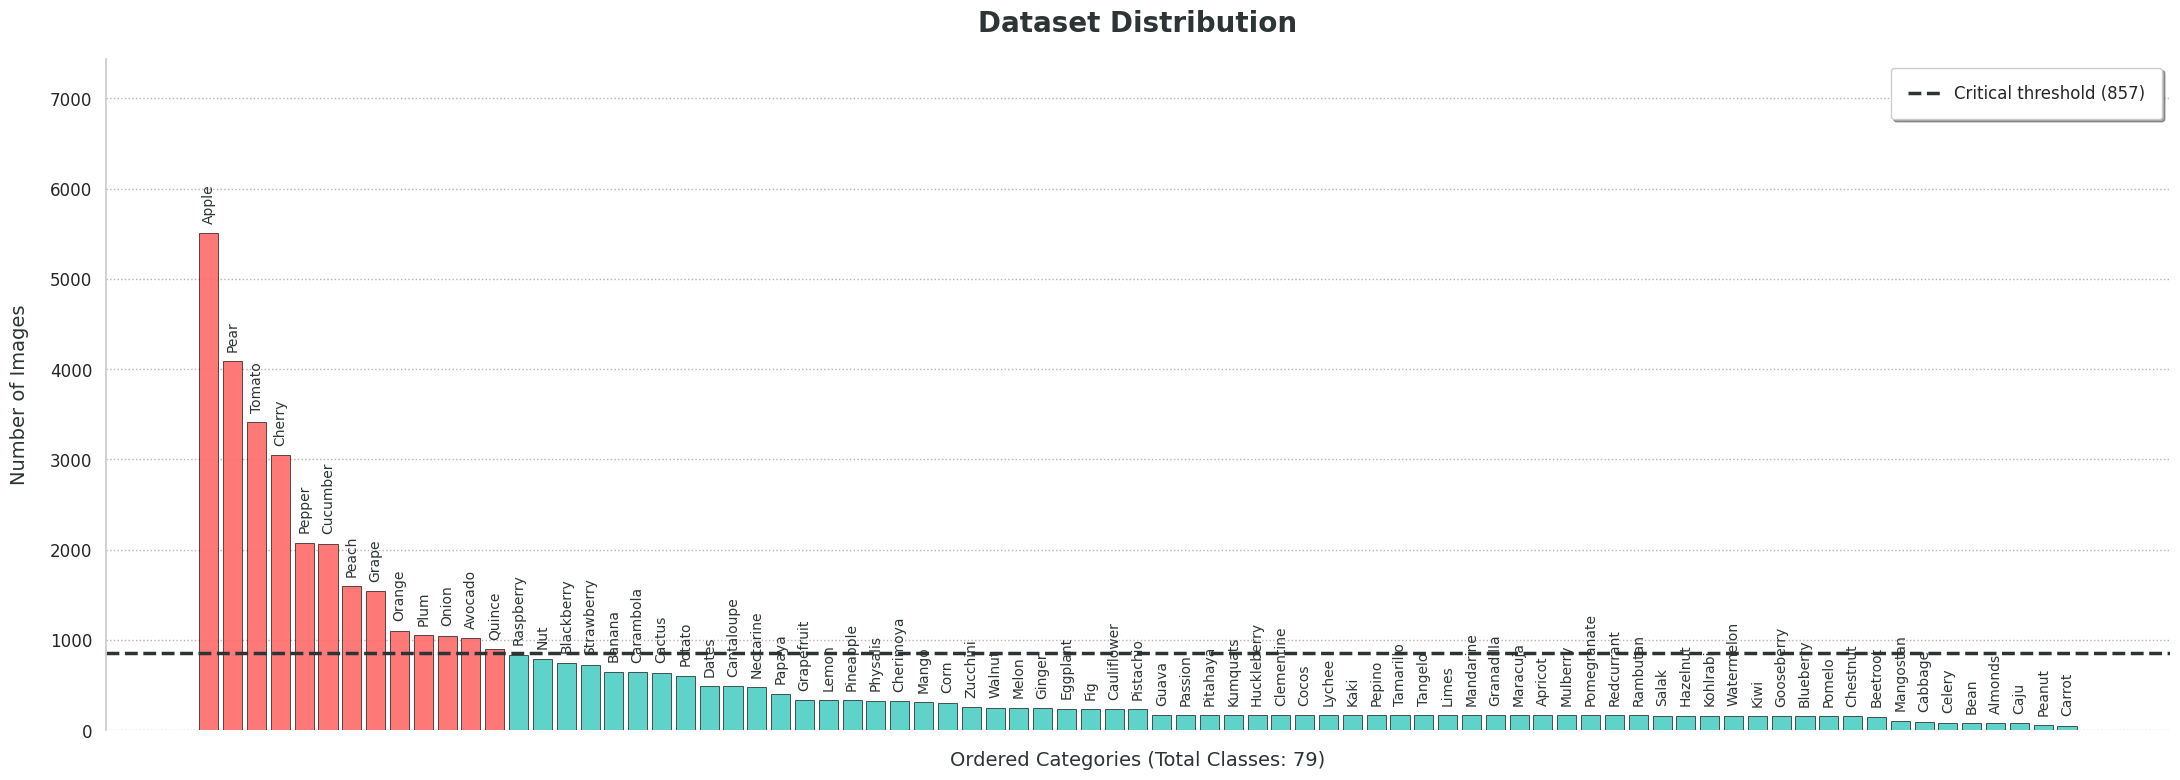

In [52]:
# Define the critical threshold for the Test set, calculated previously.
THRESHOLD_TEST = 857
# Call the function to plot the class distribution for the Test set.
plot_class_distribution(TEST_PATH, THRESHOLD_TEST)

#### Validation
**Umbral de validation**

Siguiendo la misma regla de proporción geométrica, el conjunto de validation adquiere un límite proporcional:

$$\text{Validation Threshold} = \frac{3000 \times 10}{70} \approx 428$$




Generating plot for: /content/fruits_dataset/Validation...


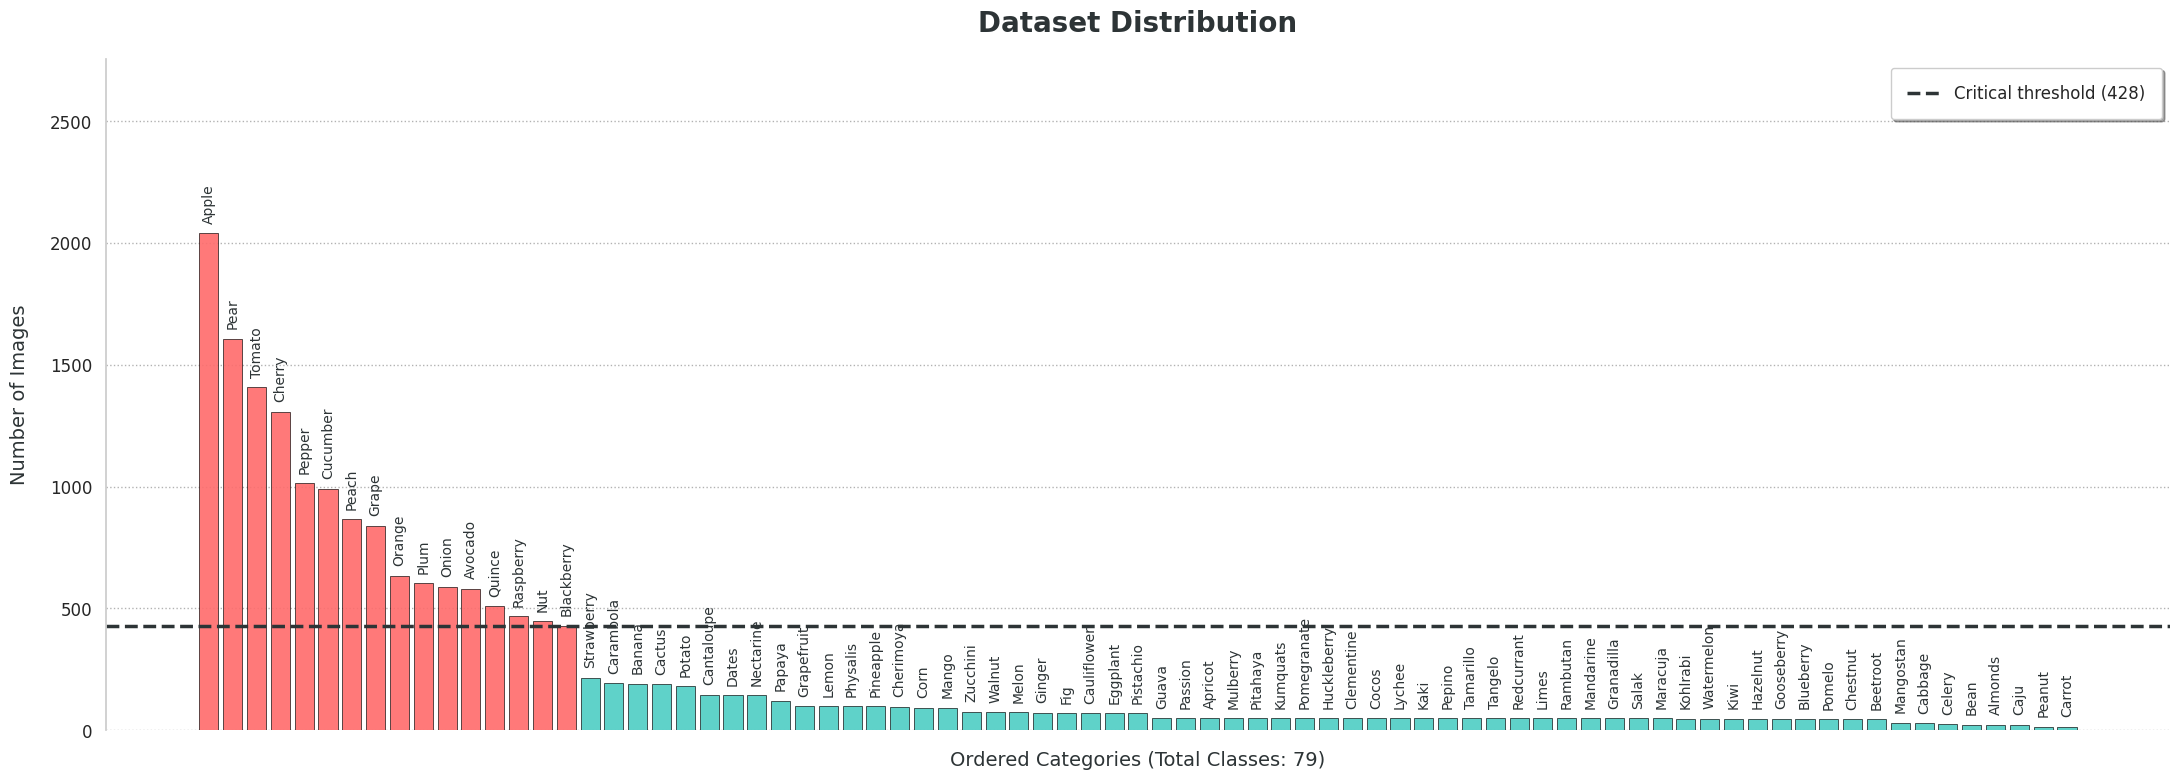

In [53]:
# Define the critical threshold for the Validation set, calculated previously.
THRESHOLD_VALIDATION = 428
# Call the function to plot the class distribution for the Validation set.
plot_class_distribution(VALIDATION_PATH, THRESHOLD_VALIDATION)

### 5.   Balanceo y aumento de datos
Existieron algunas categorías que superaban el límite establecido, para ello se recortaron las clases mayoritarias que excedían el límite, y para training con *Data Augmentation* se generaron  imágenes sintéticas para las clases minoritarias, alcanzando un balance perfecto de 3,000 imágenes por categoría.

> Nota: Se usan los límites calculados previamente para segmentar la cantidad de imágenes.



In [54]:
from PIL import Image

def apply_random_transformation(img):
    """
    Applies a random transformation (flip or rotation) to a given image.

    Args:
        img (PIL.Image.Image): The input image.

    Returns:
        PIL.Image.Image: The transformed image.
    """
    # List of possible transformations: horizontal flip, vertical flip, 90, 180, 270 degree rotations.
    transformations = [
        lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),
        lambda x: x.transpose(Image.FLIP_TOP_BOTTOM),
        lambda x: x.rotate(90, expand=True),
        lambda x: x.rotate(180, expand=True),
        lambda x: x.rotate(270, expand=True)
    ]
    # Choose a random transformation from the list.
    chosen_transform = random.choice(transformations)
    return chosen_transform(img)

In [55]:
def balance_dataset(dataset_path, critical_min, target_count, use_augmentation):
    """
    Filters, crops, and augments images in a dataset to achieve perfect balance
    or remove categories with very few data points.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
        critical_min (int): Minimum number of images for a category to be considered valid.
        target_count (int): Target number of images per category after balancing.
        use_augmentation (bool): If True, applies data augmentation for minority classes.
    """
    print(f"\nStarting balancing process in: {dataset_path}")
    print(f"Critical minimum threshold: {critical_min}")
    print(f"Target count per class: {target_count}")

    if not os.path.exists(dataset_path):
        print(f"Error! Path not found: {dataset_path}")
        return

    # Get all categories.
    categories = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]

    for category in categories:
        category_path = os.path.join(dataset_path, category)

        # Count current images in the category.
        all_images = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        current_count = len(all_images)

        # Remove: If a category has fewer images than the critical minimum.
        if current_count < critical_min:
            print(f"Deleting '{category}' outright due to insufficient data ({current_count} images).")
            shutil.rmtree(category_path) # Delete the entire category directory.
            continue # Move to the next category.

        # Crop: If a category has more images than the target count.
        elif current_count > target_count:
            print(f"Cropping excess in '{category}': {current_count} -> {target_count}")
            random.shuffle(all_images) # Shuffle images for random cropping.
            images_to_delete = all_images[target_count:] # Select images to delete.

            for img_name in images_to_delete:
                os.remove(os.path.join(category_path, img_name)) # Delete each excess image.

        # 3. Augmentation: If the category has fewer images than the target, new synthetic images are generated.
        elif current_count < target_count:
            # If augmentation is enabled
            if use_augmentation:
                images_needed = target_count - current_count # Number of images to generate.
                print(f"Applying Augmentation in '{category}': {current_count} -> {target_count}")

                for i in range(images_needed):
                    base_img_name = random.choice(all_images)
                    base_img_path = os.path.join(category_path, base_img_name)

                    try:
                        # Open the base image.
                        with Image.open(base_img_path) as img:
                            # Apply a random transformation.
                            new_img = apply_random_transformation(img)
                            new_img_name = f"aug_{i}_{base_img_name}"
                            new_img_path = os.path.join(category_path, new_img_name)

                            if new_img.mode in ("RGBA", "P"):
                                new_img = new_img.convert("RGB")

                            # Save the augmented image.
                            new_img.save(new_img_path)
                    except Exception as e:
                        print(f"Error during augmentation of {base_img_name}: {e}")


    print(f"Process completed for {dataset_path}!")

#### Training



Starting balancing process in: /content/fruits_dataset/Training
Critical minimum threshold: 2000
Target count per class: 3000
Deleting 'Guava' outright due to insufficient data (441 images).
Cropping excess in 'Onion': 3278 -> 3000
Deleting 'Carambola' outright due to insufficient data (1731 images).
Deleting 'Passion' outright due to insufficient data (441 images).
Deleting 'Walnut' outright due to insufficient data (662 images).
Deleting 'Pomelo' outright due to insufficient data (405 images).
Cropping excess in 'Quince': 3240 -> 3000
Deleting 'Cactus' outright due to insufficient data (1712 images).
Deleting 'Kiwi' outright due to insufficient data (420 images).
Deleting 'Celery' outright due to insufficient data (218 images).
Deleting 'Apricot' outright due to insufficient data (443 images).
Deleting 'Hazelnut' outright due to insufficient data (418 images).
Deleting 'Strawberry' outright due to insufficient data (1965 images).
Cropping excess in 'Orange': 3305 -> 3000
Cropping ex

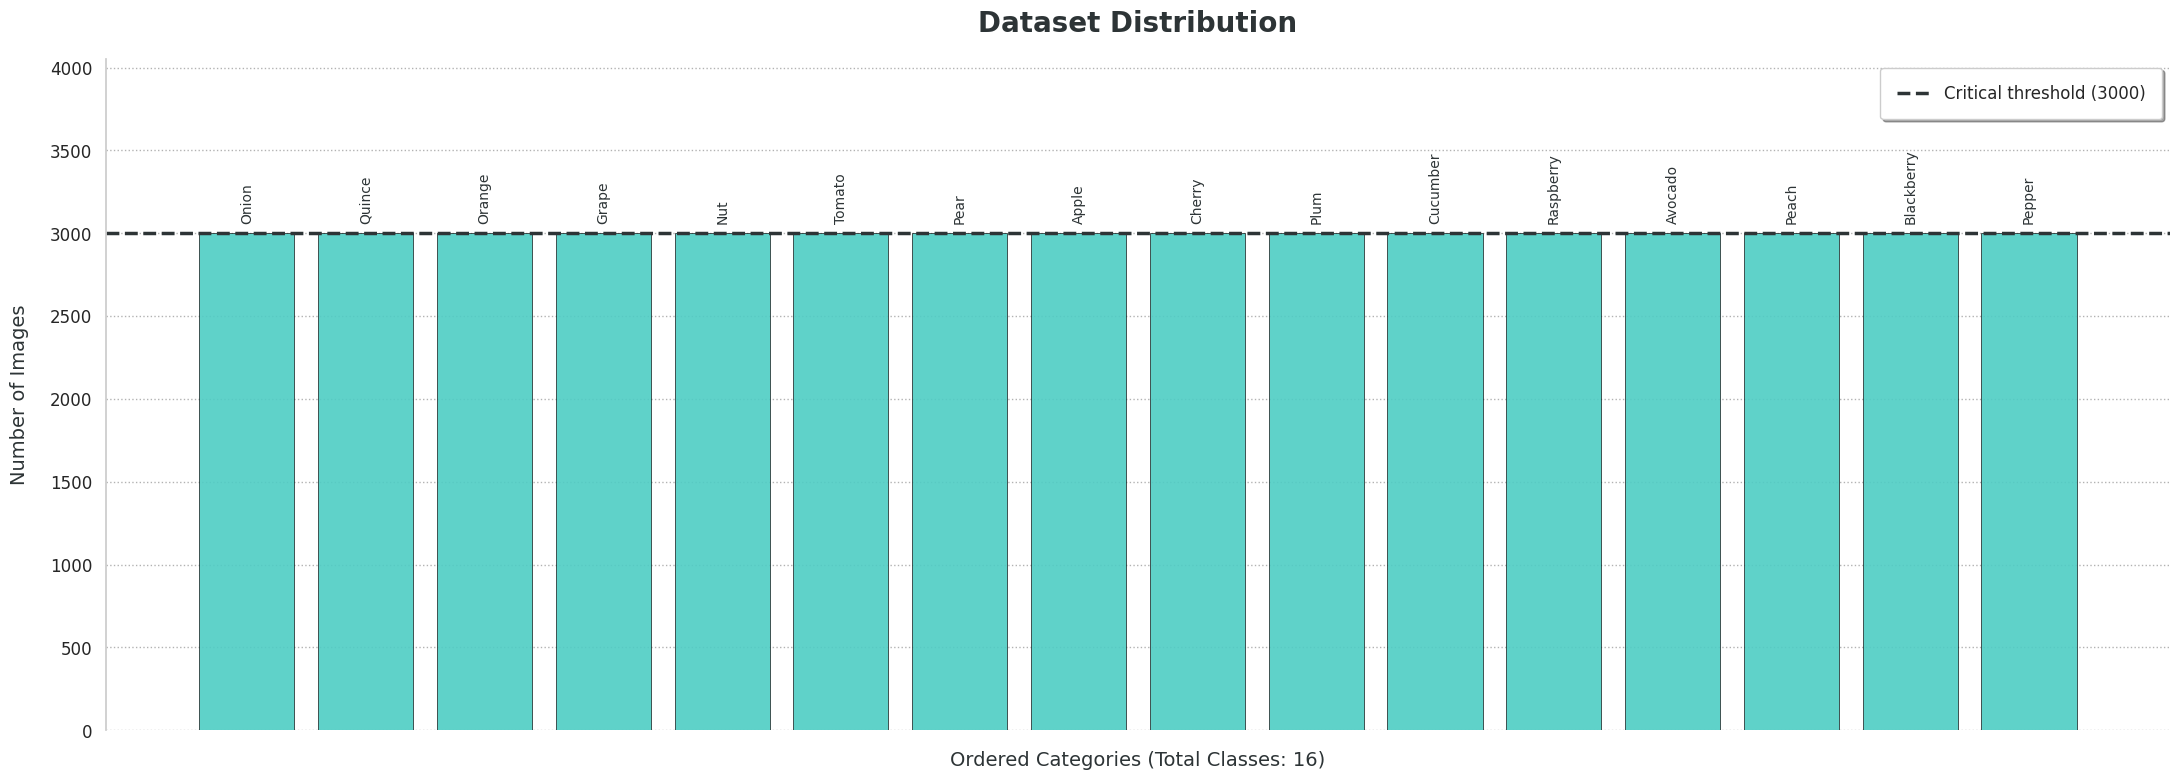

In [56]:
# Define the minimum number of images for a category and the target threshold for Training.
CRITICAL_MIN = 2000
THRESHOLD_TRAINING = 3000

# Apply the data balancing and augmentation function to the Training set.
balance_dataset(TRAINING_PATH, CRITICAL_MIN, THRESHOLD_TRAINING, True)
# Re-plot the class distribution after balancing for Training.
plot_class_distribution(TRAINING_PATH, THRESHOLD_TRAINING)

### 6.   Ajuste y sincronización
Se aplicaron recortes estrictos en los conjuntos de evaluación basándose en proporciones matemáticas. Finalmente, se sincronizaron las carpetas para eliminar clases huerfanas

In [57]:
def sync_categories(source_path, target_path):
    """
    Synchronizes the categories of 'target_path' to match those of 'source_path'.
    Deletes any folder in 'target_path' that does not exist in 'source_path'.
    To ensure that the Test and Validation sets only contain the categories that
    remained in the Training set after balancing.

    Args:
        source_path (str): Path to the reference dataset.
        target_path (str): Path to the dataset to be synchronized.
    """
    source_name = os.path.basename(source_path)
    target_name = os.path.basename(target_path)

    print()
    print(f"Synchronizing '{target_name}' with '{source_name}'")

    if not os.path.exists(source_path) or not os.path.exists(target_path):
        print("Error! Check that both paths exist in your directory.")
        return

    # Get only the folder names from both paths.
    source_categories = set([c for c in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, c))])
    target_categories = set([c for c in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, c))])

    # Find and delete excess folders in 'target_path' (those not in 'source_path').
    categories_to_delete = target_categories - source_categories

    if not categories_to_delete:
        print(f"OK: '{target_name}' has no excess classes.")
    else:
        for category in categories_to_delete:
            cat_path = os.path.join(target_path, category)
            shutil.rmtree(cat_path) # Delete the directory of the excess category.

    print(f"Synchronization finished for {target_name}")

#### Test


Starting balancing process in: /content/fruits_dataset/Test
Critical minimum threshold: 0
Target count per class: 857
Cropping excess in 'Onion': 1045 -> 857
Cropping excess in 'Quince': 897 -> 857
Cropping excess in 'Orange': 1102 -> 857
Cropping excess in 'Grape': 1538 -> 857
Cropping excess in 'Tomato': 3413 -> 857
Cropping excess in 'Pear': 4087 -> 857
Cropping excess in 'Apple': 5506 -> 857
Cropping excess in 'Cherry': 3048 -> 857
Cropping excess in 'Plum': 1053 -> 857
Cropping excess in 'Cucumber': 2065 -> 857
Cropping excess in 'Avocado': 1017 -> 857
Cropping excess in 'Peach': 1597 -> 857
Cropping excess in 'Pepper': 2074 -> 857
Process completed for /content/fruits_dataset/Test!

Synchronizing 'Test' with 'Training'
Synchronization finished for Test
Generating plot for: /content/fruits_dataset/Test...


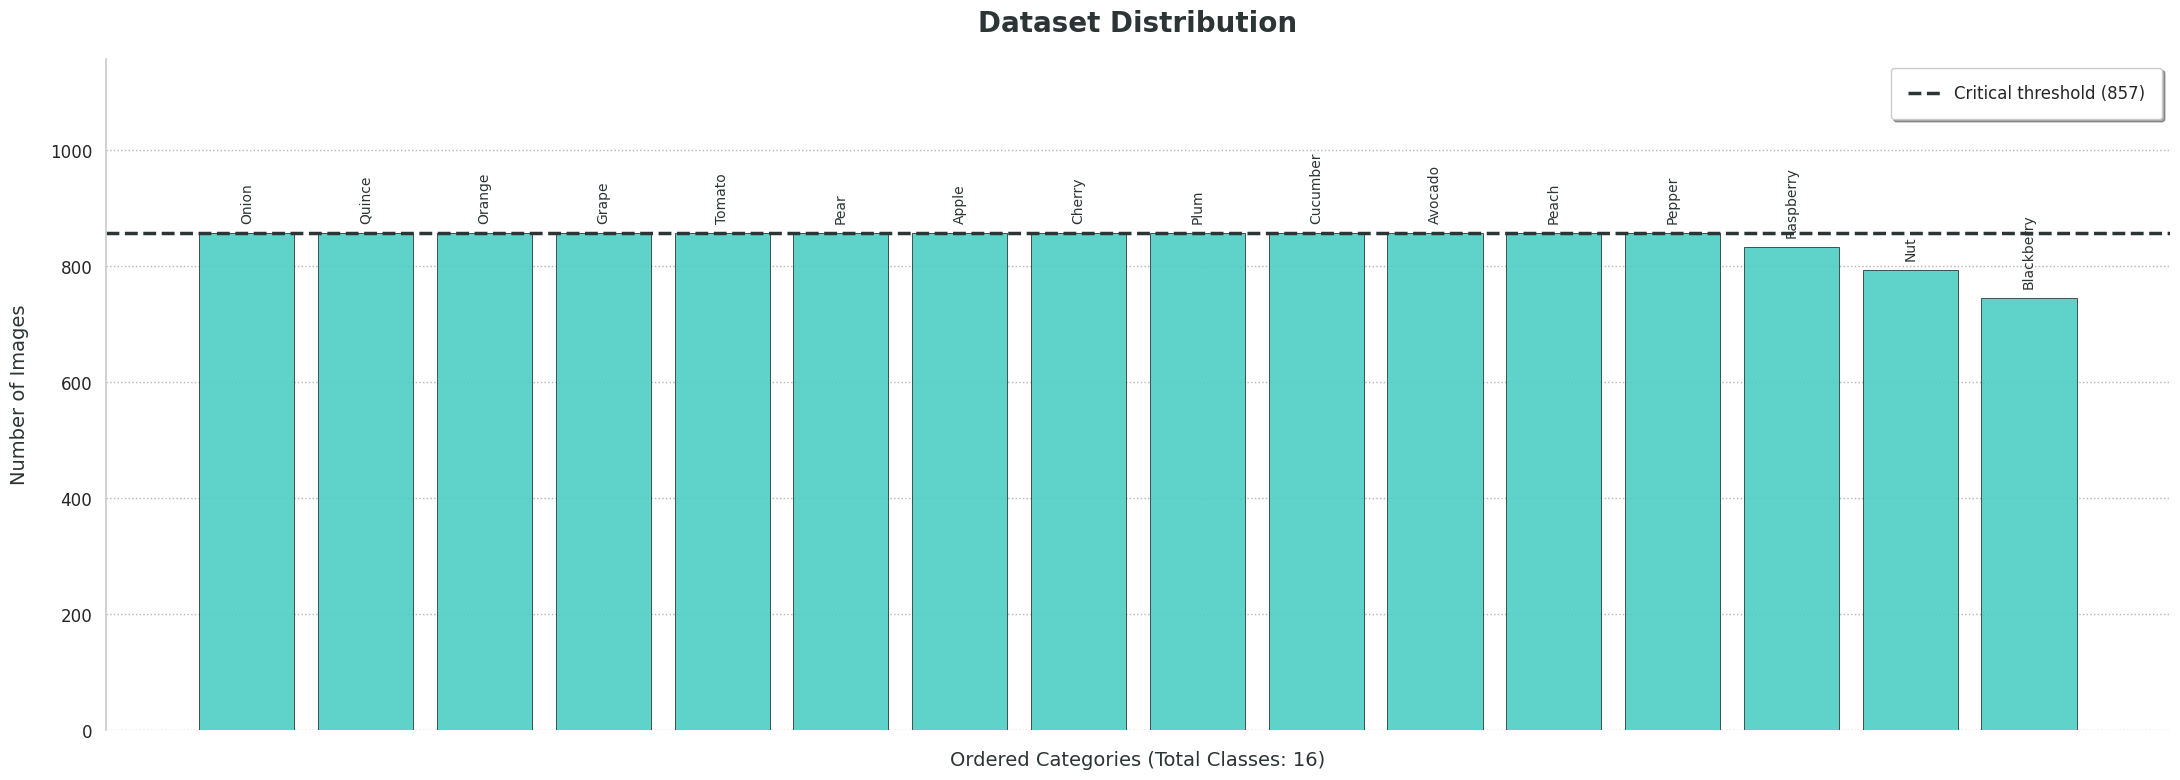

In [58]:
# Apply balancing to the Test set.
THRESHOLD_TEST = 857
balance_dataset(TEST_PATH, 0, THRESHOLD_TEST, False)

# Synchronize the categories of the Test set with those of the Training set.
sync_categories(TRAINING_PATH, TEST_PATH)

# Re-plot the class distribution after balancing and synchronization for Test.
plot_class_distribution(TEST_PATH, THRESHOLD_TEST)

#### Validation


Starting balancing process in: /content/fruits_dataset/Validation
Critical minimum threshold: 0
Target count per class: 428
Cropping excess in 'Onion': 589 -> 428
Cropping excess in 'Quince': 509 -> 428
Cropping excess in 'Orange': 635 -> 428
Cropping excess in 'Grape': 840 -> 428
Cropping excess in 'Nut': 448 -> 428
Cropping excess in 'Tomato': 1408 -> 428
Cropping excess in 'Pear': 1606 -> 428
Cropping excess in 'Apple': 2040 -> 428
Cropping excess in 'Cherry': 1308 -> 428
Cropping excess in 'Plum': 603 -> 428
Cropping excess in 'Cucumber': 990 -> 428
Cropping excess in 'Raspberry': 468 -> 428
Cropping excess in 'Avocado': 581 -> 428
Cropping excess in 'Peach': 866 -> 428
Cropping excess in 'Blackberry': 429 -> 428
Cropping excess in 'Pepper': 1013 -> 428
Process completed for /content/fruits_dataset/Validation!

Synchronizing 'Validation' with 'Training'
Synchronization finished for Validation
Generating plot for: /content/fruits_dataset/Validation...


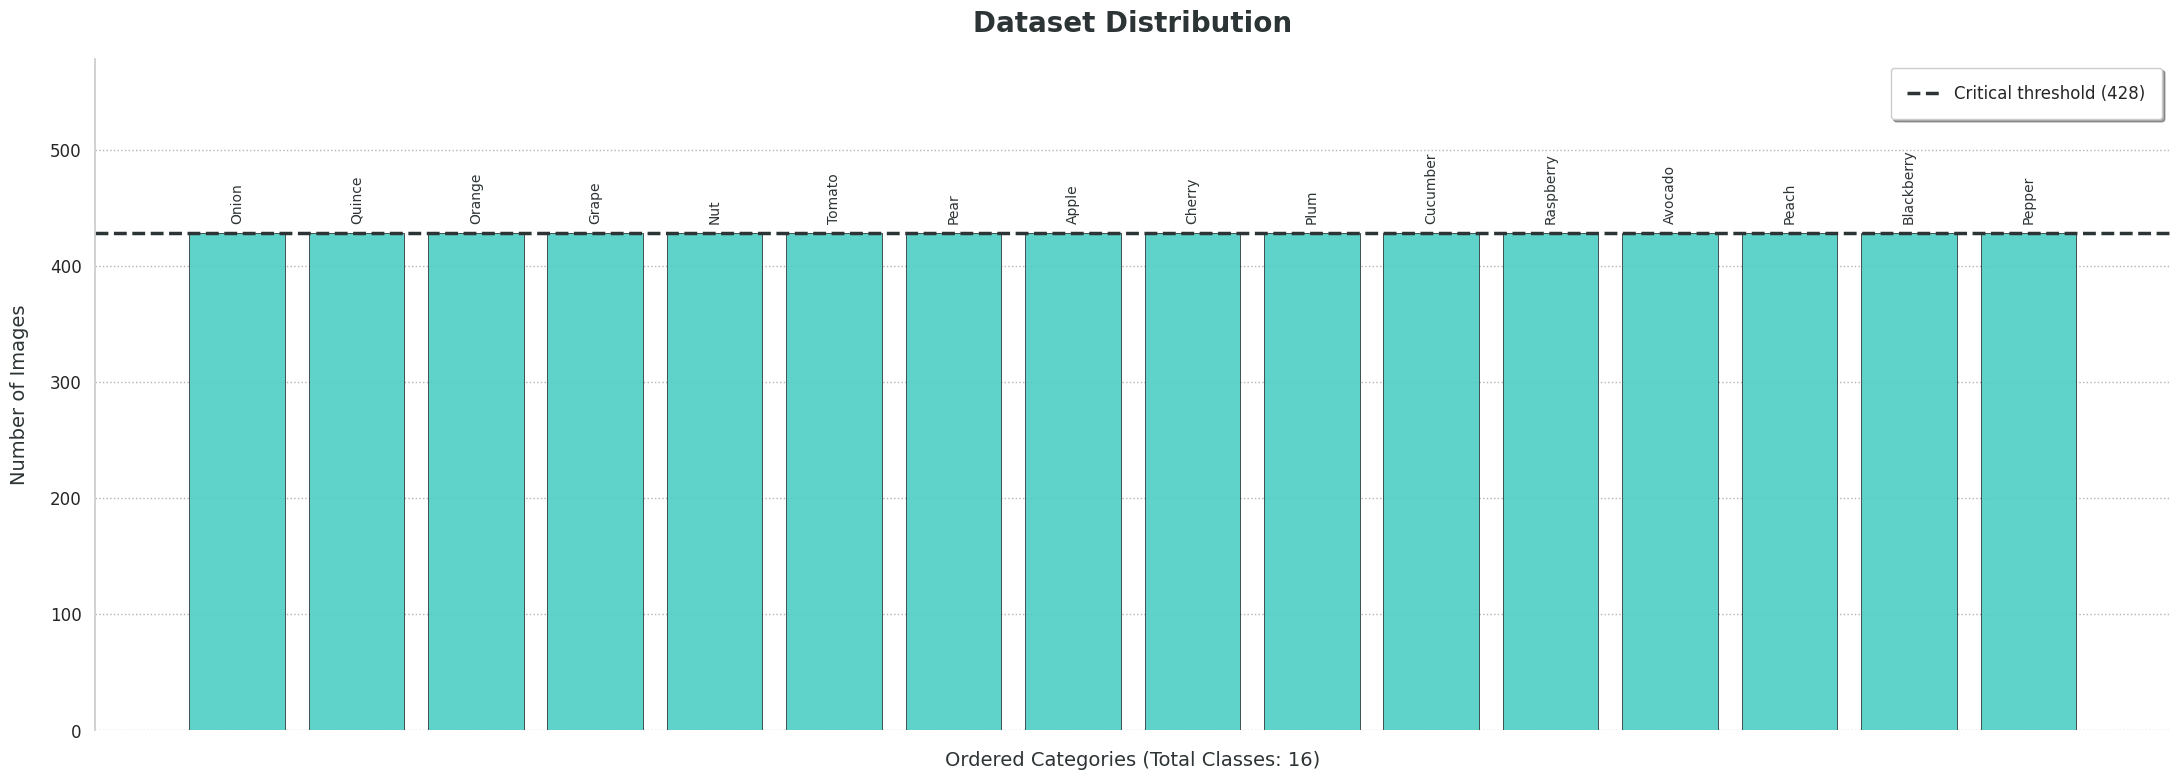

In [59]:
# Define the critical threshold for the Validation set.
THRESHOLD_VALIDATION = 428
balance_dataset(VALIDATION_PATH, 0, THRESHOLD_VALIDATION, False)

# Synchronize the categories of the Validation set with those of the Training set.
sync_categories(TRAINING_PATH, VALIDATION_PATH)

# Re-plot the class distribution after balancing and synchronization for Validation.
plot_class_distribution(VALIDATION_PATH, THRESHOLD_VALIDATION)